In [2]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util

In [1]:
!pip install --upgrade "torchao>=0.16.0" "transformers[torch]" accelerate peft datasets scipy scikit-learn

In [3]:
from google.colab import drive
drive.mount('/content/drive')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
path = '/content/drive/MyDrive/questions.csv'
from pathlib import Path

path = Path(path)
df = pd.read_csv(path)

In [5]:
df

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404346,404346,789792,789793,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404347,404347,789794,789795,Do you believe there is life after death?,Is it true that there is life after death?,1
404348,404348,789796,789797,What is one coin?,What's this coin?,0
404349,404349,789798,789799,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [6]:
import numpy as np
import torch
import torch.nn.functional as F

def compute_accuracy(model, df, batch_size=32):  # Reduced batch size for 278M param model
    print("Computing accuracy...")
    print(f"Number of question pairs: {len(df)}")
    
    thresholds = np.arange(0.5, 1.0, 0.05)
    questions1 = df["question1"].fillna("").astype(str).tolist()
    questions2 = df["question2"].fillna("").astype(str).tolist()

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Disable gradient tracking explicitly to free VRAM
    with torch.no_grad():
        emb1 = model.encode(
            questions1,
            convert_to_tensor=True,
            show_progress_bar=True,
            batch_size=batch_size,
        ).to(device)

        emb2 = model.encode(
            questions2,
            convert_to_tensor=True,
            show_progress_bar=True,
            batch_size=batch_size,
        ).to(device)

        # 1. Normalize unit vectors
        emb1_norm = F.normalize(emb1, p=2, dim=1)
        emb2_norm = F.normalize(emb2, p=2, dim=1)

        # 2. Element-wise row dot products
        cosine_scores = torch.sum(emb1_norm * emb2_norm, dim=1).cpu().numpy()

    true_labels = df["is_duplicate"].values
    accuracy = []

    for threshold in thresholds:
        predictions = (cosine_scores >= threshold).astype(int)
        accuracy.append(np.mean(predictions == true_labels))

    return accuracy, thresholds

In [ ]:
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
accuracy = compute_accuracy(model, df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing accuracy...
Number of question pairs: 404351


: 

In [9]:
accuracy, thresholds = accuracy

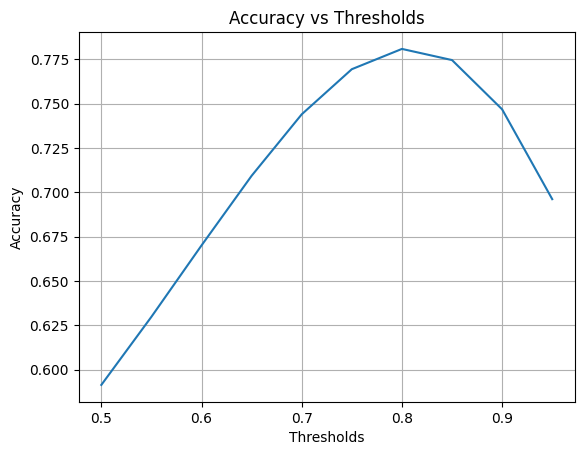

In [10]:
import matplotlib.pyplot as plt

plt.plot(thresholds, accuracy)
plt.xlabel('Thresholds')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Thresholds')
plt.grid()
plt.show()

In [7]:
loc1 = '/content/drive/MyDrive/JAMBPDF/math_jamb_siamese_mixed_duplicates.csv'
loc2 = '/content/drive/MyDrive/JAMBPDF/physics_jamb_siamese_mixed_duplicates.csv'
loc3 = '/content/drive/MyDrive/JAMBPDF/biology_jamb_contrast_rich_final.csv'

path1 = Path(loc1)
path2 = Path(loc2)
path3 = Path(loc3)

df1 = pd.read_csv(path1)
print(display(df1))

df2 = pd.read_csv(path2)
print(display(df2))

df3 = pd.read_csv(path3)
print(display(df3))




,qid,question1,question2,is_duplicate
0,0,A construction company is owned by two partner...,A software company owned by partners A and B a...,1
1,1,If M represents the median and D the mode of t...,"Using the information given, if M represents t...",1
2,2,"Given a regular hexagon, calculate each interi...","From the data provided, given a regular hexago...",1
3,3,Solve the following equations 4x – 3 = 3x + y ...,"Based on the conditions stated, solve the foll...",1
4,4,If x = 1 is root of the equation x3 – 2x2 – 5x...,Consider the problem where if x = 1 is root of...,1
...,...,...,...,...
3996,3996,Peter’s weekly wages are #20.00 for the first ...,"If the scores of 3students in a test are 5,6 a...",0
3997,3997,"The variance of the scores 1,2,3,4,5 is",Find the area bounded by the curves y = 4 – x2,0
3998,3998,"In XYZ above, determine the cosine of angle Z","If (x - 1), (x + 1) and (x - 2) are factors of...",0
3999,3999,"Find the equation of the locus of a point P(x,...",Find the range of values of x for which x + 2/...,0


None


,qid,question1,question2,is_duplicate
0,0,"In a resonance tube experiment, a tube of fixe...",Determine the result for the following: in a r...,1
1,1,Which of the following is NOT a vector quantity,Which option below is NOT a vector quantity,1
2,2,P1 P3 O O3 O2 P2 the figure Consider the three...,"Using the information given, p1 P3 O O3 O2 P2 ...",1
3,3,Cord Pull the figure A brick at rest on a hori...,Consider the following problem: cord Pull the ...,1
4,4,The force with which an object is attracted to...,Determine the force with which an object is at...,1
...,...,...,...,...
3996,3996,Equal masses of copper and rubber are raised t...,Which of the following correctly represents th...,0
3997,3997,What happens when a certain quantity of pure i...,The heat produced in a conductor carrying an e...,0
3998,3998,Download MySchoolGist JAMB CBT Software from h...,The resistances of a platinum wire at the ice ...,0
3999,3999,Which of the following pairs is NOT part of th...,If a ray traveling in air is incident on a tra...,0


None


,qid,question1,question2,is_duplicate
0,0,The sex of a foetus is determined during,When is the sex of a foetus established?,1
1,1,The part labelled II is the,The most important environmental factor which ...,0
2,2,Most monocots are easily recognized by their,The villus in the small intestine is significa...,0
3,3,The function of the long-winged reproductives ...,There will be agglutination when the,0
4,4,The end products of the digestion of fats and ...,Which simpler substances result from digestion...,1
...,...,...,...,...
995,995,When a healthy shoot of a flowering plant is i...,A flowering plant is monoecious if,0
996,996,If the phloem of a healthy plant is killed by ...,Fossil records found in sedimentary rocks offe...,0
997,997,The gas occupying the space labelled I is,What is gas occupying the space labelled I?,1
998,998,The main organic substances found in the human...,What are the principal organic substances pres...,1


None


In [8]:
df_final = pd.concat([df1, df2], ignore_index=True)
df_final = pd.concat([df_final, df3], ignore_index=True)
df_final.isnull().sum()

,0
qid,0
question1,0
question2,0
is_duplicate,0


In [9]:
df_final.duplicated().sum()
df_final = df_final.drop_duplicates().reset_index()

In [10]:
np.random.seed(42)
indices = np.random.randint(0, high=404000, size=15000)
df3 = df.iloc[indices]
df3 = df3.reset_index()
df3 = df3.drop(columns=['id', 'index'])
df3

,qid1,qid2,question1,question2,is_duplicate
0,241680,241681,What are some questions to ask a girl you like?,What questions should I ask to girls?,0
1,290598,290599,I just had a very bad break up. My boyfriend l...,What did you do when your ex moved on?,0
2,261309,261310,Does Quora form intellectual bubbles?,Who owns the intellectual property of Quora?,0
3,716079,716080,What is the superstition behind a twitching ri...,What is the superstition of the lower left eye...,1
4,510083,510084,If universe is expanding without a limit and d...,How is dark/vacuum energy created with the uni...,1
...,...,...,...,...,...
14995,188255,188256,How can I stop feeling inferior around others?,How do you stop the feeling of inferiority?,0
14996,501986,501987,I am 18 male and my vocal range d#2-f#6 what v...,I am 18 male and my vocal range d#2-f#6 what t...,1
14997,145228,145229,Is it bad to do aerobic exercise everyday?,"I am 26,suffering from vitiligo from7 years th...",0
14998,47772,47773,What are some examples of metals found in comets?,What are some examples of metals found in aste...,0


In [11]:
df_final2 = pd.concat([df_final, df3], ignore_index=True).drop_duplicates().reset_index()

df_final2 = df_final2.drop(columns=['level_0', 'qid', 'index', 'qid1', 'qid2'])

df_final2


,question1,question2,is_duplicate
0,A construction company is owned by two partner...,A software company owned by partners A and B a...,1
1,If M represents the median and D the mode of t...,"Using the information given, if M represents t...",1
2,"Given a regular hexagon, calculate each interi...","From the data provided, given a regular hexago...",1
3,Solve the following equations 4x – 3 = 3x + y ...,"Based on the conditions stated, solve the foll...",1
4,If x = 1 is root of the equation x3 – 2x2 – 5x...,Consider the problem where if x = 1 is root of...,1
...,...,...,...
23721,How can I stop feeling inferior around others?,How do you stop the feeling of inferiority?,0
23722,I am 18 male and my vocal range d#2-f#6 what v...,I am 18 male and my vocal range d#2-f#6 what t...,1
23723,Is it bad to do aerobic exercise everyday?,"I am 26,suffering from vitiligo from7 years th...",0
23724,What are some examples of metals found in comets?,What are some examples of metals found in aste...,0


In [12]:
df_final2.isnull().sum()

,0
question1,0
question2,0
is_duplicate,0


In [13]:
import os
import re
import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModel, AutoTokenizer

# 1. Text normalization function (Safe for Yoruba diacritics and STEM)
def normalize_math_text(text):
    text = str(text).lower()
    operators = [r"\+", r"-", r"–", r"=", r"\*", r"/", r"÷"]
    for op in operators:
        text = re.sub(f"({op})", r" \1 ", text)
    return re.sub(r"\s+", " ", text).strip()

# Apply normalization directly
df_final2['question1'] = df_final2['question1'].fillna("").apply(normalize_math_text)
df_final2['question2'] = df_final2['question2'].fillna("").apply(normalize_math_text)

# 2. Multilingual Model Configuration
model_id = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
base_model = AutoModel.from_pretrained(model_id)

# 3. Configure LoRA for XLM-RoBERTa architecture
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['query', 'value'],  # Target attention projections in XLM-RoBERTa
    bias='none',
    task_type=TaskType.FEATURE_EXTRACTION  # Native PEFT task for AutoModel feature extraction
)

# 4. Inject adapters FIRST, then move entire architecture to GPU
model = get_peft_model(base_model, lora_config)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

trainable params: 589,824 || all params: 278,633,472 || trainable%: 0.2117


In [18]:
# I really need to take that huggingface course to fully understand how the dataset module works why it returns dicts etc
# And how automodel, autoseq2seqlm etc draw the model and what params are to be passed into pefts LoraConfig
raw_dataset = Dataset.from_pandas(df_final2)

def tokenize_function(data):
    tok1 = tokenizer(
        data['question1'],
        padding='max_length',
        truncation=True,
        max_length=128,
    )
    tok2 = tokenizer(
        data['question2'],
        padding='max_length',
        truncation=True,
        max_length=128,
    )
    return {
        "input_ids1": tok1["input_ids"],
        "attention_mask1": tok1["attention_mask"],
        "input_ids2": tok2["input_ids"],
        "attention_mask2": tok2["attention_mask"],
        "labels": data["is_duplicate"],
    }

# 1. Map tokenization across dataset
tokenized_dataset = raw_dataset.map(tokenize_function, batched=True)

# 2. Split into DatasetDict ('train' and 'test')
tokenized_datasets = tokenized_dataset.train_test_split(test_size=0.1, seed=42)

# 3. CRITICAL: Enforce PyTorch tensor casting on your custom keys
required_columns = ["input_ids1", "attention_mask1", "input_ids2", "attention_mask2", "labels"]
tokenized_datasets.set_format(type="torch", columns=required_columns)

Map:   0%|          | 0/26727 [00:00<?, ? examples/s]

In [21]:
import torch
from transformers import Trainer, TrainingArguments

class SiameseTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        input_ids1, mask1 = inputs.get("input_ids1"), inputs.get("attention_mask1")
        input_ids2, mask2 = inputs.get("input_ids2"), inputs.get("attention_mask2")
        labels = inputs.get("labels").float()

        outputs1 = model(input_ids=input_ids1, attention_mask=mask1)
        outputs2 = model(input_ids=input_ids2, attention_mask=mask2)

        emb1 = self._mean_pooling(outputs1, mask1)
        emb2 = self._mean_pooling(outputs2, mask2)

        cosine_sim = torch.cosine_similarity(emb1, emb2, dim=1)
        loss_fct = torch.nn.MSELoss()
        loss = loss_fct(cosine_sim, labels)

        return (loss, cosine_sim) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        """Overrides evaluation loop to prevent input_ids missing error during eval."""
        with torch.no_grad():
            loss, cosine_sim = self.compute_loss(model, inputs, return_outputs=True)
            
        if prediction_loss_only:
            return (loss, None, None)
            
        return (loss, cosine_sim, inputs.get("labels"))

    def _mean_pooling(self, model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = (
            attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        )
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask


# 6. Optimized System Execution Parameters
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/JAMBPDF/exam_similarity_model",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    learning_rate=2e-4,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,  # CRITICAL: Retains input_ids1, input_ids2, etc.
)

# 7. Initialize and Run the Pipeline
trainer = SiameseTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

print("Starting custom fine-tuning execution...")
trainer.train()

Starting custom fine-tuning execution...


ImportError: cannot import name 'VideoReader' from 'torchvision.io' (/usr/local/lib/python3.12/dist-packages/torchvision/io/__init__.py)

In [ ]:
import os
import pathlib

# Define a single, unified output path
save_path = pathlib.Path("/content/drive/MyDrive/JAMBPDF/question_duplicate2")

# Save both adapter weights and tokenizer to the same directory
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Final LoRA weights and tokenizer saved successfully!")
print(os.listdir(save_path))

Final LoRA weights and tokenizer saved successfully!
['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Run inference across the test split
eval_results = trainer.predict(tokenized_datasets["test"])
scores = eval_results.predictions  # Predicted cosine similarities
labels = eval_results.label_ids

# 2. Sweep thresholds from 0.50 to 0.90 to maximize F1-score
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.50, 0.90, 0.02):
    preds = (scores >= thresh).astype(int)
    report = classification_report(labels, preds, output_dict=True, zero_division=0)
    f1 = report["1"]["f1-score"]  # Focus on duplicate detection performance
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

print(f"Optimal Cosine Threshold: {best_thresh:.2f} | Peak Duplicate F1-Score: {best_f1:.4f}")

Optimal Cosine Threshold: 0.64 | Peak Duplicate F1-Score: 0.8785


In [ ]:
print('ok')

ok


In [ ]:
import torch
import numpy as np
import pandas as pd
from peft import PeftModel
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Path configuration & Model loading
model_path = "/content/drive/MyDrive/JAMBPDF/question_duplicate2"
base_model_id = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

tokenizer = AutoTokenizer.from_pretrained(model_path)
base_model = AutoModel.from_pretrained(base_model_id)

# Merge trained LoRA adapter weights with base architecture
model = PeftModel.from_pretrained(base_model, model_path)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# 2. Mask-aware mean pooling function
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

# 3. Batched similarity scoring function
def compute_df_similarities(df, batch_size=64):
    q1_list = df['question1'].astype(str).tolist()
    q2_list = df['question2'].astype(str).tolist()
    similarities = []

    for i in range(0, len(q1_list), batch_size):
        batch_q1 = q1_list[i:i+batch_size]
        batch_q2 = q2_list[i:i+batch_size]

        tok1 = tokenizer(batch_q1, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        tok2 = tokenizer(batch_q2, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)

        with torch.no_grad():
            out1 = model(**tok1)
            out2 = model(**tok2)

            emb1 = mean_pooling(out1, tok1['attention_mask'])
            emb2 = mean_pooling(out2, tok2['attention_mask'])

            cosine_sim = torch.cosine_similarity(emb1, emb2, dim=1)
            similarities.extend(cosine_sim.cpu().numpy())

    return np.array(similarities)

# 4. Run inference on DataFrame
print("Generating vector embeddings and computing cosine similarities...")
df_final2['similarity_score'] = compute_df_similarities(df_final2)
y_true = df_final2['is_duplicate'].values

# 5. Threshold sweep to determine peak Accuracy and F1-score
best_threshold = 0.50
best_acc = 0.0

print("\n--- Model Accuracy Across Decision Thresholds ---")
for thresh in np.arange(0.50, 0.90, 0.05):
    preds = (df_final2['similarity_score'] >= thresh).astype(int)
    acc = accuracy_score(y_true, preds)
    print(f"Cosine Cutoff: {thresh:.2f} | Overall Accuracy: {acc * 100:.2f}%")
    
    if acc > best_acc:
        best_acc = acc
        best_threshold = thresh

print(f"\n==================================================")
print(f"PEAK ACCURACY: {best_acc * 100:.2f}% at Cutoff Threshold: {best_threshold:.2f}")
print(f"==================================================")

# 6. Detailed Classification Metrics at Optimal Cutoff
best_preds = (df_final2['similarity_score'] >= best_threshold).astype(int)
print("\nDetailed Performance Breakdown:")
print(classification_report(y_true, best_preds, target_names=["Not Duplicate (0)", "Duplicate (1)"]))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Generating vector embeddings and computing cosine similarities...

--- Model Accuracy Across Decision Thresholds ---
Cosine Cutoff: 0.50 | Overall Accuracy: 90.56%
Cosine Cutoff: 0.55 | Overall Accuracy: 91.21%
Cosine Cutoff: 0.60 | Overall Accuracy: 91.53%
Cosine Cutoff: 0.65 | Overall Accuracy: 91.67%
Cosine Cutoff: 0.70 | Overall Accuracy: 91.36%
Cosine Cutoff: 0.75 | Overall Accuracy: 90.69%
Cosine Cutoff: 0.80 | Overall Accuracy: 89.62%
Cosine Cutoff: 0.85 | Overall Accuracy: 87.97%

PEAK ACCURACY: 91.67% at Cutoff Threshold: 0.65

Detailed Performance Breakdown:
                   precision    recall  f1-score   support

Not Duplicate (0)       0.93      0.92      0.93     15223
    Duplicate (1)       0.90      0.91      0.90     11504

         accuracy                           0.92     26727
        macro avg       0.91      0.92      0.92     26727
     weighted avg       0.92      0.92      0.92     26727



In [ ]:
import torch
import numpy as np
import pandas as pd
from peft import PeftModel
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Path configuration & Model loading
model_path = "/content/drive/MyDrive/JAMBPDF/question_duplicate2"
base_model_id = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

tokenizer = AutoTokenizer.from_pretrained(model_path)
base_model = AutoModel.from_pretrained(base_model_id)

# Merge trained LoRA adapter weights with base architecture
model = PeftModel.from_pretrained(base_model, model_path)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# 2. Mask-aware mean pooling function
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

# 3. Batched similarity scoring function
def compute_df_similarities(df, batch_size=64):
    q1_list = df['question1'].astype(str).tolist()
    q2_list = df['question2'].astype(str).tolist()
    similarities = []

    for i in range(0, len(q1_list), batch_size):
        batch_q1 = q1_list[i:i+batch_size]
        batch_q2 = q2_list[i:i+batch_size]

        tok1 = tokenizer(batch_q1, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        tok2 = tokenizer(batch_q2, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)

        with torch.no_grad():
            out1 = model(**tok1)
            out2 = model(**tok2)

            emb1 = mean_pooling(out1, tok1['attention_mask'])
            emb2 = mean_pooling(out2, tok2['attention_mask'])

            cosine_sim = torch.cosine_similarity(emb1, emb2, dim=1)
            similarities.extend(cosine_sim.cpu().numpy())

    return np.array(similarities)

# 4. Run inference on DataFrame
print("Generating vector embeddings and computing cosine similarities...")
df['similarity_score'] = compute_df_similarities(df)
y_true = df['is_duplicate'].values

# 5. Threshold sweep to determine peak Accuracy and F1-score
best_threshold = 0.50
best_acc = 0.0

print("\n--- Model Accuracy Across Decision Thresholds ---")
for thresh in np.arange(0.50, 0.90, 0.05):
    preds = (df['similarity_score'] >= thresh).astype(int)
    acc = accuracy_score(y_true, preds)
    print(f"Cosine Cutoff: {thresh:.2f} | Overall Accuracy: {acc * 100:.2f}%")
    
    if acc > best_acc:
        best_acc = acc
        best_threshold = thresh

print(f"\n==================================================")
print(f"PEAK ACCURACY: {best_acc * 100:.2f}% at Cutoff Threshold: {best_threshold:.2f}")
print(f"==================================================")

# 6. Detailed Classification Metrics at Optimal Cutoff
best_preds = (df['similarity_score'] >= best_threshold).astype(int)
print("\nDetailed Performance Breakdown:")
print(classification_report(y_true, best_preds, target_names=["Not Duplicate (0)", "Duplicate (1)"]))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generating vector embeddings and computing cosine similarities...

--- Model Accuracy Across Decision Thresholds ---
Cosine Cutoff: 0.50 | Overall Accuracy: 77.46%
Cosine Cutoff: 0.55 | Overall Accuracy: 78.91%
Cosine Cutoff: 0.60 | Overall Accuracy: 79.83%
Cosine Cutoff: 0.65 | Overall Accuracy: 80.20%
Cosine Cutoff: 0.70 | Overall Accuracy: 79.87%
Cosine Cutoff: 0.75 | Overall Accuracy: 78.90%
Cosine Cutoff: 0.80 | Overall Accuracy: 77.17%
Cosine Cutoff: 0.85 | Overall Accuracy: 74.55%

PEAK ACCURACY: 80.20% at Cutoff Threshold: 0.65

Detailed Performance Breakdown:
                   precision    recall  f1-score   support

Not Duplicate (0)       0.85      0.83      0.84    255045
    Duplicate (1)       0.72      0.75      0.74    149306

         accuracy                           0.80    404351
        macro avg       0.79      0.79      0.79    404351
     weighted avg       0.80      0.80      0.80    404351



In [ ]:
df

In [15]:
from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader

# 1. Load multilingual base model for sequence classification
model_name = "xlm-roberta-base"
cross_encoder = CrossEncoder(model_name, num_labels=2)  # Regression output (0.0 to 1.0)

# 2. Format training samples from your DataFrame
train_examples = [
    InputExample(texts=[row['question1'], row['question2']], label=int(row['is_duplicate']))
    for _, row in df_final2.iterrows()
]

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# 3. Fine-tune for 2-3 epochs (Cross-encoders converge rapidly)
cross_encoder.fit(
    train_dataloader=train_dataloader,
    epochs=3,
    warmup_steps=100,
    output_path="/content/drive/MyDrive/JAMBPDF/cross_encoder_yoruba_stem",
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


OutOfMemoryError: CUDA out of memory. Tried to allocate 734.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 579.81 MiB is free. Process 9207 has 10.31 GiB memory in use. Including non-PyTorch memory, this process has 3.69 GiB memory in use. Of the allocated memory 3.16 GiB is allocated by PyTorch, and 408.80 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [34]:
import os
import pathlib
from google.colab import drive
from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader

# 2. Define output directory as a string
output_dir = "/content/drive/MyDrive/JAMBPDF/cross_encoder_yoruba_stem"
os.makedirs(output_dir, exist_ok=True)
cross_encoder.save(output_dir)

print("Saved files in directory:")
print(os.listdir(output_dir))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved files in directory:
['config_sentence_transformers.json', 'config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'sentence_bert_config.json', 'modules.json', 'README.md']


In [35]:
from sentence_transformers import CrossEncoder
import numpy as np

loc4 = str(pathlib.Path("/content/drive/MyDrive/JAMBPDF/cross_encoder_yoruba_stem"))

# Load fine-tuned Stage 2 Cross-Encoder
reranker = CrossEncoder(loc4)

def verify_duplicates(new_question, candidate_questions, stage1_indices):
    """
    new_question: str
    candidate_questions: list of str (retrieved via Stage 1 Bi-Encoder where sim >= 0.60)
    stage1_indices: list of int (original question IDs in exam bank)
    """
    if not candidate_questions:
        return []

    # Prepare pairs for joint cross-attention
    pairs = [[new_question, cand] for cand in candidate_questions]
    
    # Compute cross-encoder probability scores (0.0 to 1.0)
    scores = reranker.predict(pairs)  
    
    # Enforce strict threshold (e.g., >= 0.85) for final duplicate flag
    CROSS_THRESHOLD = 0.85
    verified_duplicates = [
        {"question_id": stage1_indices[i], "score": float(scores[i])}
        for i in range(len(scores))
        if scores[i] >= CROSS_THRESHOLD
    ]
    
    return verified_duplicates

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [17]:
import re
import torch
import numpy as np
from peft import PeftModel
from transformers import AutoModel, AutoTokenizer
from sentence_transformers import CrossEncoder

# ---------------------------------------------------------
# 1. Setup Models & Paths
# ---------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# Stage 1 Bi-Encoder Paths
stage1_path = "/content/drive/MyDrive/JAMBPDF/question_duplicate2"
base_model_id = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

# Stage 2 Cross-Encoder Path
stage2_path = "/content/drive/MyDrive/JAMBPDF/cross_encoder_yoruba_stem"

print("Loading Stage 1 Bi-Encoder...")
tokenizer = AutoTokenizer.from_pretrained(stage1_path)
base_model = AutoModel.from_pretrained(base_model_id)
bi_encoder = PeftModel.from_pretrained(base_model, stage1_path).to(device)
bi_encoder.eval()

print("Loading Stage 2 Cross-Encoder...")
cross_encoder = CrossEncoder(str(stage2_path))
print(cross_encoder.config.id2label)

# ---------------------------------------------------------
# 2. Text Normalization Function
# ---------------------------------------------------------
def normalize_math_text(text):
    text = str(text).lower()
    operators = [r"\+", r"-", r"–", r"=", r"\*", r"/", r"÷"]
    for op in operators:
        text = re.sub(f"({op})", r" \1 ", text)
    return re.sub(r"\s+", " ", text).strip()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

# ---------------------------------------------------------
# 3. Test Cases Configuration
# ---------------------------------------------------------
raw_new_question = "Find the roots of the quadratic equation 2x^2 - 5x + 3 = 0."

candidates = [
    {"id": 101, "text": "Solve for x in 2x^2 - 5x + 3 = 0.", "expected": "Duplicate"},
    {"id": 102, "text": "Determine the values of x that satisfy the quadratic equation 2x^2 - 5x + 3 = 0.", "expected": "Duplicate"},
    {"id": 103, "text": "Find the minimum value of the function f(x) = 2x^2 - 5x + 3.", "expected": "Not Duplicate"},
    {"id": 104, "text": "Find the roots of the quadratic equation 2x^2 + 5x - 3 = 0.", "expected": "Not Duplicate"},
    {"id": 105, "text": "Calculate the derivative of sin(x) with respect to x.", "expected": "Not Duplicate"}
]

# Apply math normalization
new_q_norm = normalize_math_text(raw_new_question)
cand_texts_norm = [normalize_math_text(c["text"]) for c in candidates]

# ---------------------------------------------------------
# 4. Stage 1: Bi-Encoder Candidate Filtering
# ---------------------------------------------------------
print("\n=== RUNNING STAGE 1: Bi-Encoder Cosine Retrieval ===")

# Tokenize & encode query
q_tok = tokenizer([new_q_norm], padding=True, truncation=True, return_tensors="pt").to(device)
c_tok = tokenizer(cand_texts_norm, padding=True, truncation=True, return_tensors="pt").to(device)

with torch.no_grad():
    q_emb = mean_pooling(bi_encoder(**q_tok), q_tok['attention_mask'])
    c_embs = mean_pooling(bi_encoder(**c_tok), c_tok['attention_mask'])
    
    # Compute Cosine Similarities
    q_norm_vec = q_emb / torch.norm(q_emb, dim=1, keepdim=True)
    c_norm_vecs = c_embs / torch.norm(c_embs, dim=1, keepdim=True)
    stage1_scores = torch.mm(q_norm_vec, c_norm_vecs.T).squeeze(0).cpu().numpy()

stage1_candidates = []
STAGE1_THRESHOLD = 0.60

for idx, score in enumerate(stage1_scores):
    cand = candidates[idx]
    passed = score >= STAGE1_THRESHOLD
    print(f"Cand ID {cand['id']} | Cosine Sim: {score:.4f} | Stage 1 Filter: {'PASSED' if passed else 'REJECTED'}")
    if passed:
        stage1_candidates.append((idx, cand, score))

# ---------------------------------------------------------
# 5. Stage 2: Cross-Encoder High-Precision Verification
# ---------------------------------------------------------
print("\n=== RUNNING STAGE 2: Cross-Encoder Joint Reranking ===")

if not stage1_candidates:
    print("No candidates retrieved from Stage 1.")
else:
    # Prepare pairs passed from Stage 1
    pairs_to_verify = [[raw_new_question, cand["text"]] for _, cand, _ in stage1_candidates]
    stage2_scores = cross_encoder.predict(pairs_to_verify)
    
    STAGE2_THRESHOLD = 0.85
    
    print(f"\n{'ID':<6} | {'Expected':<13} | {'Stage 1 Sim':<12} | {'Stage 2 Logit/Prob':<18} | {'Final Decision':<15}")
    print("-" * 75)
    
    for i, (orig_idx, cand, s1_score) in enumerate(stage1_candidates):
        s2_score = float(stage2_scores[i])
        is_dup = s2_score >= STAGE2_THRESHOLD
        verdict = "DUPLICATE" if is_dup else "NOT DUPLICATE"
        
        print(f"{cand['id']:<6} | {cand['expected']:<13} | {s1_score:.4f}        | {s2_score:.4f}             | {verdict:<15}")

Loading Stage 1 Bi-Encoder...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading Stage 2 Cross-Encoder...


Loading weights:   0%|          | 0/201 [00:04<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 5.81 MiB is free. Process 9207 has 10.31 GiB memory in use. Including non-PyTorch memory, this process has 4.25 GiB memory in use. Of the allocated memory 3.98 GiB is allocated by PyTorch, and 133.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [18]:
import gc
import torch

# Delete lingering model/embedding variables if present
for var in ['bi_encoder', 'base_model', 'emb1', 'emb2', 'model']:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()

# Verify freed memory
free_mem = torch.cuda.mem_get_info()[0] / 1e9
print(f"Free VRAM: {free_mem:.2f} GB")

Free VRAM: 0.90 GB
